In [1]:
# Installation du wrapper pour connecter Keras à Scikit-Learn
!pip install scikeras

# Mise à jour optionnelle des bibliothèques de base (souvent déjà à jour sur Colab Pro)
!pip install -U scikit-learn tensorflow joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 120.7 MB/s eta 0:00:00
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.19.0
    Uninstalling tensorboard-2.19.0:
      Successfully uninstalled tensorboard-2.19.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.19.0
    Uninstalling tensorflow-2.19.0:
      Successfully uninstalled tensorflow-2.19.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensor

Chargement des données...
Lancement de l'optimisation Deep Learning...
Fitting 2 folds for each of 5 candidates, totalling 10 fits
Meilleurs paramètres : {'model__n_neurons': 64, 'model__n_layers': 2, 'model__learning_rate': 0.001, 'batch_size': 256}
R2 Final DL : 0.6570


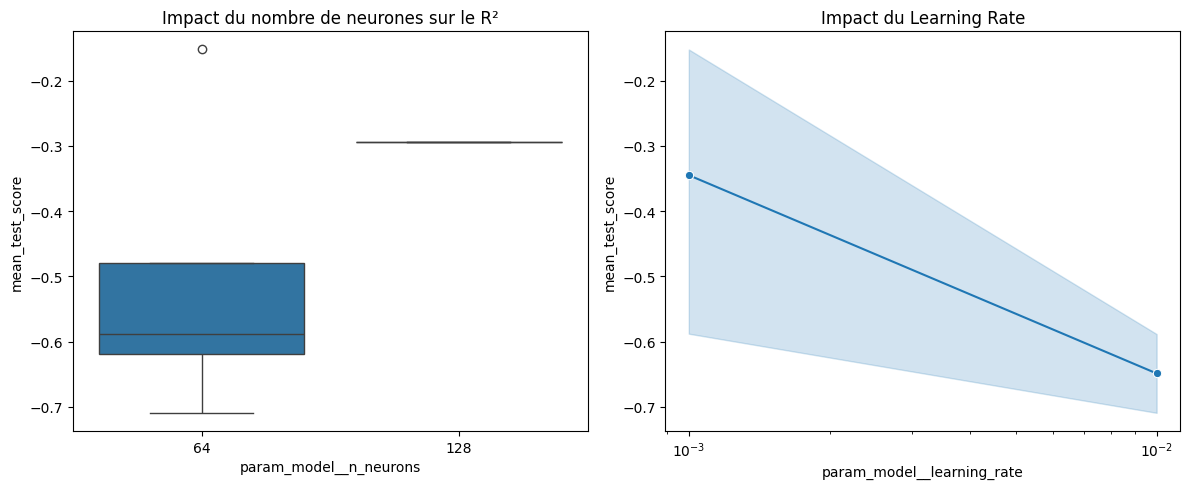

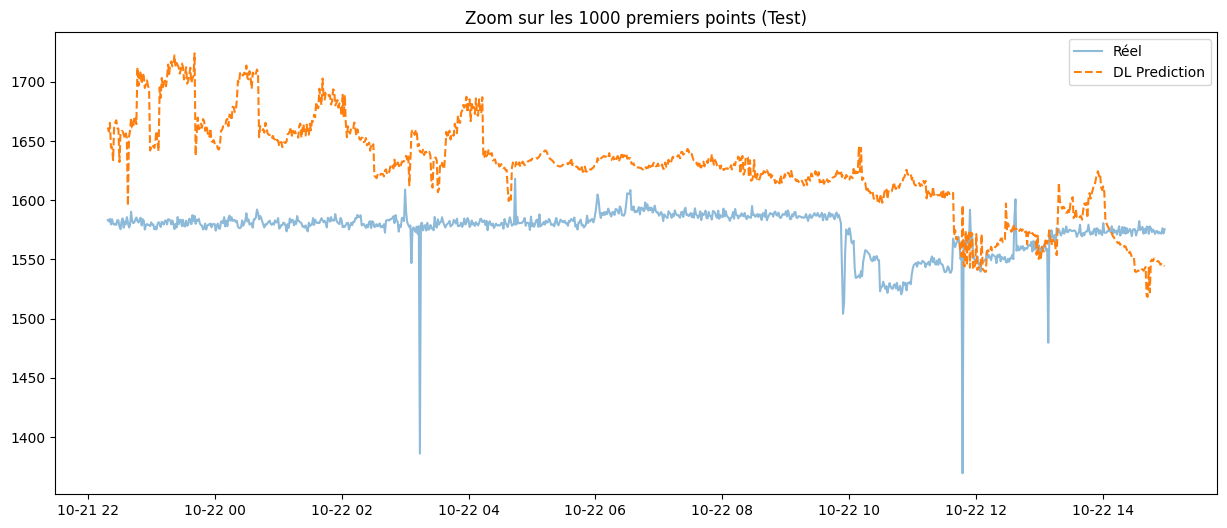

['imputer_final.pkl']

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from scikeras.wrappers import KerasRegressor # Nécessite : pip install scikeras
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ==========================================
# 1. PRÉPARATION (Identique à avant)
# ==========================================
print("Chargement des données...")
df = pd.read_csv('data_prod_finale.csv', parse_dates=['time'], index_col='time')
df = df.sort_index()

X = df.drop(columns=['target'])
y = df['target']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(imputer.fit_transform(X_train_raw))
X_test_scaled = scaler.transform(imputer.transform(X_test_raw))

# ==========================================
# 2. CONSTRUCTION DU MODÈLE DL (FONCTION)
# ==========================================
def create_model(n_layers=2, n_neurons=64, dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],))) # 37 features

    # Ajout dynamique des couches cachées
    for _ in range(n_layers):
        model.add(Dense(n_neurons, activation='relu'))
        model.add(Dropout(dropout_rate))

    # Couche de sortie (Régression = 1 neurone, pas d'activation)
    model.add(Dense(1))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

# ==========================================
# 3. OPTIMISATION (RANDOMIZED SEARCH)
# ==========================================
print("Lancement de l'optimisation Deep Learning...")

# Wrapper pour Sklearn
dl_wrapper = KerasRegressor(
    model=create_model,
    epochs=20, # On réduit pour le search, on augmentera pour le final
    batch_size=256,
    verbose=0,
    n_layers=2,
    n_neurons=64,
    dropout_rate=0.2,
    learning_rate=0.001
)

# Grille de paramètres
param_dist = {
    'model__n_layers': [2, 3],
    'model__n_neurons': [64, 128],
    'model__learning_rate': [0.01, 0.001],
    'batch_size': [128, 256]
}

tscv = TimeSeriesSplit(n_splits=2) # On réduit les splits pour la vitesse

# On teste 5 combinaisons au hasard parmi la grille
random_search = RandomizedSearchCV(
    estimator=dl_wrapper,
    param_distributions=param_dist,
    n_iter=5,
    cv=tscv,
    scoring='r2',
    verbose=1
)

random_search.fit(X_train_scaled, y_train)

# ==========================================
# 4. RÉSULTATS ET GRAPHIQUES
# ==========================================
print(f"Meilleurs paramètres : {random_search.best_params_}")

# Sauvegarde du meilleur modèle
best_dl = random_search.best_estimator_
y_pred = best_dl.predict(X_test_scaled)

print(f"R2 Final DL : {r2_score(y_test, y_pred):.4f}")

# --- GRAPHIQUE D'OPTIMISATION ---
cv_results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(12, 5))

# Score vs Nombre de Neurones
plt.subplot(1, 2, 1)
sns.boxplot(x='param_model__n_neurons', y='mean_test_score', data=cv_results)
plt.title('Impact du nombre de neurones sur le R²')

# Score vs Learning Rate
plt.subplot(1, 2, 2)
sns.lineplot(x='param_model__learning_rate', y='mean_test_score', data=cv_results, marker='o')
plt.xscale('log')
plt.title('Impact du Learning Rate')

plt.tight_layout()
plt.show()

# --- GRAPHIQUE RÉEL VS PRÉDIT ---
plt.figure(figsize=(15, 6))
plt.plot(y_test.index[:1000], y_test.values[:1000], label='Réel', alpha=0.5)
plt.plot(y_test.index[:1000], y_pred[:1000], label='DL Prediction', linestyle='--')
plt.title('Zoom sur les 1000 premiers points (Test)')
plt.legend()
plt.show()

# Sauvegarde des fichiers
joblib.dump(best_dl, 'model_DL_final.pkl')
joblib.dump(scaler, 'scaler_final.pkl')
joblib.dump(imputer, 'imputer_final.pkl')

In [3]:
import pandas as pd
import numpy as np
import joblib
from scikeras.wrappers import KerasRegressor

# 1. CHARGEMENT DES COMPOSANTS (Modèle et Transformateurs)
print("Chargement des composants...")
try:
    imputer = joblib.load('imputer_final.pkl')
    scaler = joblib.load('scaler_final.pkl')
    model_dl = joblib.load('model_DL_final.pkl')
    print("Tous les composants sont chargés.")
except FileNotFoundError as e:
    print(f"Erreur : Fichier manquant -> {e}")

# 2. CHARGEMENT DE LA PREMIÈRE LIGNE DU DATASET RÉEL
# On charge le CSV original pour prendre une vraie ligne
df_real = pd.read_csv('data_prod_finale.csv')

# On prend la première ligne (index 0)
first_row = df_real.iloc[0]

# On sépare les caractéristiques (X) et la cible réelle (y)
# On retire 'time' si c'est l'index ou une colonne, et 'target'
y_realite = first_row['target']
X_brut = first_row.drop(['target', 'time'], errors='ignore')

# 3. LISTE OFFICIELLE DES FEATURES (pour l'ordre)
features_list = [
    'Niveau_reservoir', 'DECISION_BACKWASH_NUM', 'DP_moyen_filtres', 'type_backwash',
    'duree_backwash', 'intervalle_min', 'freq_backwash', 'INDICE_ENCRASSEMENT_HMMF',
    'DEBIT_ENTREE_HMMF', 'INDICE_IMPACT_PRODUCTION', 'INDICE_DESEQUILIBRE_FILTRES',
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B',
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D',
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H',
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J',
    'HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF-E', 'HMMF-F', 'HMMF-G', 'HMMF-H',
    'HMMF-I', 'HMMF-J'
]


# 4. PRÉPARATION DE LA DONNÉE POUR LE MODÈLE
# On convertit la ligne en DataFrame et on aligne les colonnes
X_input = pd.DataFrame([X_brut])
X_input = X_input[features_list]

# Étape 1 : Imputation
X_imputed = imputer.transform(X_input)

# Étape 2 : Scaling
X_scaled = scaler.transform(X_imputed)

# 5. PRÉDICTION ET COMPARAISON
prediction = model_dl.predict(X_scaled)

print("\n" + "="*50)
print("TEST SUR LA PREMIÈRE LIGNE DU DATASET")
print("="*50)
print(f"RÉALITÉ (Valeur cible du CSV) : {y_realite:.4f}")
print(f"PRÉDICTION (Deep Learning)    : {prediction[0]:.4f}")
print("-" * 50)
error = abs(y_realite - prediction[0])
print(f"ERREUR ABSOLUE                : {error:.4f}")
print("="*50)

Chargement des composants...
Tous les composants sont chargés.

TEST SUR LA PREMIÈRE LIGNE DU DATASET
RÉALITÉ (Valeur cible du CSV) : 1437.2312
PRÉDICTION (Deep Learning)    : 1342.8066
--------------------------------------------------
ERREUR ABSOLUE                : 94.4246
